In [0]:
gold_path = "dbfs:/Volumes/workspace/default/foodbank_data/gold/weekly_demand"

gold_df = spark.read.format("delta").load(gold_path)
display(gold_df)



year,week,location_id,visit_count
2024,1,BocaRaton,124
2024,1,Boynton,80
2024,1,Deerfield,96
2024,1,Delray,123
2024,44,BocaRaton,155
2024,44,Boynton,103
2024,44,Deerfield,124
2024,44,Delray,154
2024,45,BocaRaton,388
2024,45,Boynton,248


In [0]:
ml_df = gold_df.select("week", "visit_count")
display(ml_df)


week,visit_count
1,124
1,80
1,96
1,123
44,155
44,103
44,124
44,154
45,388
45,248


In [0]:
ml_pd = ml_df.toPandas()
ml_pd.head()


,week,visit_count
0,1,124
1,1,80
2,1,96
3,1,123
4,44,155


In [0]:
X = ml_pd[["week"]]
y = ml_pd["visit_count"]


In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [0]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [0]:
y_pred = model.predict(X_test)


In [0]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae


76.29923031101079

In [0]:
ml_df = gold_df.select("year", "week", "location_id", "visit_count")
display(ml_df)


year,week,location_id,visit_count
2024,1,BocaRaton,124
2024,1,Boynton,80
2024,1,Deerfield,96
2024,1,Delray,123
2024,44,BocaRaton,155
2024,44,Boynton,103
2024,44,Deerfield,124
2024,44,Delray,154
2024,45,BocaRaton,388
2024,45,Boynton,248


In [0]:
ml_pd = ml_df.toPandas()
ml_pd.head()


,year,week,location_id,visit_count
0,2024,1,BocaRaton,124
1,2024,1,Boynton,80
2,2024,1,Deerfield,96
3,2024,1,Delray,123
4,2024,44,BocaRaton,155


In [0]:
import pandas as pd
ml_encoded = pd.get_dummies(ml_pd, columns=["location_id"])
ml_encoded.head()


,year,week,visit_count,location_id_BocaRaton,location_id_Boynton,location_id_Deerfield,location_id_Delray
0,2024,1,124,True,False,False,False
1,2024,1,80,False,True,False,False
2,2024,1,96,False,False,True,False
3,2024,1,123,False,False,False,True
4,2024,44,155,True,False,False,False


In [0]:
ml_encoded = pd.get_dummies(ml_pd, columns=["location_id"])
ml_encoded.head()


,year,week,visit_count,location_id_BocaRaton,location_id_Boynton,location_id_Deerfield,location_id_Delray
0,2024,1,124,True,False,False,False
1,2024,1,80,False,True,False,False
2,2024,1,96,False,False,True,False
3,2024,1,123,False,False,False,True
4,2024,44,155,True,False,False,False


In [0]:
X = ml_encoded.drop("visit_count", axis=1)
y = ml_encoded["visit_count"]


In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [0]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [0]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mae


45.53571314753731

In [0]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison_df.head()


,Actual,Predicted
0,389,357.667575
1,399,390.263947
2,392,352.702495
3,323,310.001060
4,155,375.368708


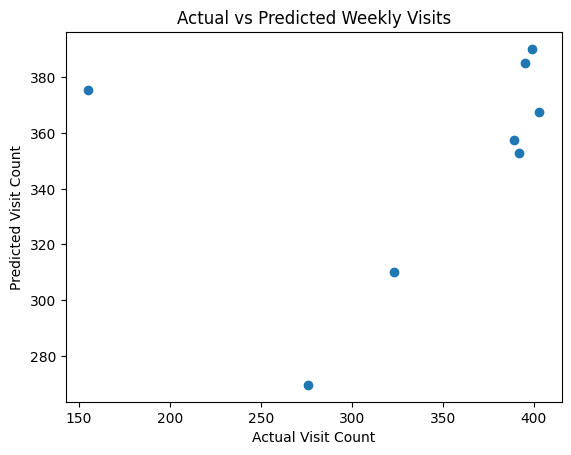

In [0]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(comparison_df["Actual"], comparison_df["Predicted"])
plt.xlabel("Actual Visit Count")
plt.ylabel("Predicted Visit Count")
plt.title("Actual vs Predicted Weekly Visits")
plt.show()


In [0]:
ml_results = X_test.copy()
ml_results["actual_visit_count"] = y_test.values
ml_results["predicted_visit_count"] = y_pred


In [0]:
ml_results_spark = spark.createDataFrame(ml_results)
display(ml_results_spark)


year,week,location_id_BocaRaton,location_id_Boynton,location_id_Deerfield,location_id_Delray,actual_visit_count,predicted_visit_count
2024,47,false,false,false,true,389,357.66757493188015
2024,47,true,false,false,false,399,390.2639466513696
2024,46,false,false,false,true,392,352.7024953391654
2024,49,false,false,true,false,323,310.00105964274906
2024,44,true,false,false,false,155,375.36870787322533
2024,46,true,false,false,false,395,385.2988670586548
2024,52,false,true,false,false,276,269.55132495179816
2024,49,false,false,false,true,403,367.59773411730964


In [0]:
ml_path = "dbfs:/Volumes/workspace/default/foodbank_data/gold/ml_predictions"

ml_results_spark.write.format("delta").mode("overwrite").save(ml_path)


In [0]:
dbutils.fs.ls("dbfs:/Volumes/workspace/default/foodbank_data/gold/")


[FileInfo(path='dbfs:/Volumes/workspace/default/foodbank_data/gold/avg_household_size/', name='avg_household_size/', size=0, modificationTime=1765993480672),
 FileInfo(path='dbfs:/Volumes/workspace/default/foodbank_data/gold/ml_predictions/', name='ml_predictions/', size=0, modificationTime=1765993480672),
 FileInfo(path='dbfs:/Volumes/workspace/default/foodbank_data/gold/weekly_demand/', name='weekly_demand/', size=0, modificationTime=1765993480672)]

In [0]:
dbutils.fs.mkdirs(
    "dbfs:/Volumes/workspace/default/foodbank_data/exports"
)


True

In [0]:
(
    spark.read.format("delta")
    .load("dbfs:/Volumes/workspace/default/foodbank_data/gold/weekly_demand")
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", "true")
    .csv("dbfs:/Volumes/workspace/default/foodbank_data/exports/weekly_demand")
)


In [0]:
dbutils.fs.ls(
    "dbfs:/Volumes/workspace/default/foodbank_data/exports/weekly_demand"
)


[FileInfo(path='dbfs:/Volumes/workspace/default/foodbank_data/exports/weekly_demand/_SUCCESS', name='_SUCCESS', size=0, modificationTime=1765993793000),
 FileInfo(path='dbfs:/Volumes/workspace/default/foodbank_data/exports/weekly_demand/_committed_46372584710378870', name='_committed_46372584710378870', size=111, modificationTime=1765993793000),
 FileInfo(path='dbfs:/Volumes/workspace/default/foodbank_data/exports/weekly_demand/_started_46372584710378870', name='_started_46372584710378870', size=0, modificationTime=1765993792000),
 FileInfo(path='dbfs:/Volumes/workspace/default/foodbank_data/exports/weekly_demand/part-00000-tid-46372584710378870-27ccec16-3a4d-4a51-a6c3-711026ffe1d5-225-1-c000.csv', name='part-00000-tid-46372584710378870-27ccec16-3a4d-4a51-a6c3-711026ffe1d5-225-1-c000.csv', size=858, modificationTime=1765993793000)]

In [0]:
pred_df = spark.read.format("delta").load(
    "dbfs:/Volumes/workspace/default/foodbank_data/gold/ml_predictions"
)


In [0]:
pred_df.show(5)


+----+----+-----------+-----------+----------+--------+------------------+
|year|week|location_id|visit_count|week_index|features|        prediction|
+----+----+-----------+-----------+----------+--------+------------------+
|2024|   1|  BocaRaton|        124|         0|   [0.0]|  184.710975609756|
|2024|   1|    Boynton|         80|         1|   [1.0]| 190.7719512195121|
|2024|   1|  Deerfield|         96|         2|   [2.0]| 196.8329268292682|
|2024|   1|     Delray|        123|         3|   [3.0]| 202.8939024390243|
|2024|  44|  BocaRaton|        155|         4|   [4.0]|208.95487804878042|
+----+----+-----------+-----------+----------+--------+------------------+
only showing top 5 rows


In [0]:
from pyspark.sql.functions import col, abs


In [0]:
eval_df = pred_df.withColumn(
    "error",
    col("visit_count") - col("prediction")
).withColumn(
    "abs_error",
    abs(col("visit_count") - col("prediction"))
)


In [0]:
eval_df.select(
    "year", "week", "location_id",
    "visit_count", "prediction",
    "error", "abs_error"
).show(10)


+----+----+-----------+-----------+------------------+-------------------+------------------+
|year|week|location_id|visit_count|        prediction|              error|         abs_error|
+----+----+-----------+-----------+------------------+-------------------+------------------+
|2024|   1|  BocaRaton|        124|  184.710975609756| -60.71097560975599| 60.71097560975599|
|2024|   1|    Boynton|         80| 190.7719512195121|-110.77195121951209|110.77195121951209|
|2024|   1|  Deerfield|         96| 196.8329268292682|-100.83292682926819|100.83292682926819|
|2024|   1|     Delray|        123| 202.8939024390243| -79.89390243902429| 79.89390243902429|
|2024|  44|  BocaRaton|        155|208.95487804878042|-53.954878048780415|53.954878048780415|
|2024|  44|    Boynton|        103| 215.0158536585365|-112.01585365853651|112.01585365853651|
|2024|  44|  Deerfield|        124| 221.0768292682926| -97.07682926829261| 97.07682926829261|
|2024|  44|     Delray|        154| 227.1378048780487| -73.1

In [0]:
from pyspark.sql.functions import avg


In [0]:
mae = eval_df.select(avg("abs_error")).first()[0]
print("Mean Absolute Error:", mae)

Mean Absolute Error: 70.0390243902439


In [0]:
(
    eval_df
    .write
    .format("delta")
    .mode("overwrite")
    .save("dbfs:/Volumes/workspace/default/foodbank_data/gold/model_evaluation")
)



In [0]:
#Improve the ML model by teaching it that different locations behave differently

In [0]:
weekly_df = spark.read.format("delta").load(
    "dbfs:/Volumes/workspace/default/foodbank_data/gold/weekly_demand"
)


In [0]:
from pyspark.ml.feature import StringIndexer


In [0]:
location_indexer = StringIndexer(
    inputCol="location_id",
    outputCol="location_index"
)

weekly_df = location_indexer.fit(weekly_df).transform(weekly_df)


In [0]:
from pyspark.ml.feature import VectorAssembler


In [0]:
assembler = VectorAssembler(
    inputCols=["week_index", "location_index"],
    outputCol="features"
)

ml_df = assembler.transform(weekly_df)


In [0]:
from pyspark.sql.functions import row_number
from pyspark.sql.window import Window


In [0]:
window_spec = Window.orderBy("year", "week", "location_id")


In [0]:
weekly_df = weekly_df.withColumn(
    "week_index",
    row_number().over(window_spec) - 1
)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
weekly_df.select(
    "year", "week", "location_id", "week_index"
).show(10)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----+----+-----------+----------+
|year|week|location_id|week_index|
+----+----+-----------+----------+
|2024|   1|  BocaRaton|         0|
|2024|   1|    Boynton|         1|
|2024|   1|  Deerfield|         2|
|2024|   1|     Delray|         3|
|2024|  44|  BocaRaton|         4|
|2024|  44|    Boynton|         5|
|2024|  44|  Deerfield|         6|
|2024|  44|     Delray|         7|
|2024|  45|  BocaRaton|         8|
|2024|  45|    Boynton|         9|
+----+----+-----------+----------+
only showing top 10 rows


In [0]:
pred_path = "dbfs:/Volumes/workspace/default/foodbank_data/gold/ml_predictions"

pred_df = (
    spark.read
    .format("delta")
    .load(pred_path)
)

pred_df.show(5)


+----+----+-----------+-----------+----------+--------+------------------+
|year|week|location_id|visit_count|week_index|features|        prediction|
+----+----+-----------+-----------+----------+--------+------------------+
|2024|   1|  BocaRaton|        124|         0|   [0.0]|  184.710975609756|
|2024|   1|    Boynton|         80|         1|   [1.0]| 190.7719512195121|
|2024|   1|  Deerfield|         96|         2|   [2.0]| 196.8329268292682|
|2024|   1|     Delray|        123|         3|   [3.0]| 202.8939024390243|
|2024|  44|  BocaRaton|        155|         4|   [4.0]|208.95487804878042|
+----+----+-----------+-----------+----------+--------+------------------+
only showing top 5 rows


In [0]:
from pyspark.sql.functions import col, abs

ml_results = (
    pred_df
    .select("year", "week", "location_id", "visit_count", "prediction")
    .withColumn("error", col("visit_count") - col("prediction"))
    .withColumn("abs_error", abs(col("visit_count") - col("prediction")))
)

ml_results.show(10)


+----+----+-----------+-----------+------------------+-------------------+------------------+
|year|week|location_id|visit_count|        prediction|              error|         abs_error|
+----+----+-----------+-----------+------------------+-------------------+------------------+
|2024|   1|  BocaRaton|        124|  184.710975609756| -60.71097560975599| 60.71097560975599|
|2024|   1|    Boynton|         80| 190.7719512195121|-110.77195121951209|110.77195121951209|
|2024|   1|  Deerfield|         96| 196.8329268292682|-100.83292682926819|100.83292682926819|
|2024|   1|     Delray|        123| 202.8939024390243| -79.89390243902429| 79.89390243902429|
|2024|  44|  BocaRaton|        155|208.95487804878042|-53.954878048780415|53.954878048780415|
|2024|  44|    Boynton|        103| 215.0158536585365|-112.01585365853651|112.01585365853651|
|2024|  44|  Deerfield|        124| 221.0768292682926| -97.07682926829261| 97.07682926829261|
|2024|  44|     Delray|        154| 227.1378048780487| -73.1

In [0]:
ml_results_path = "dbfs:/Volumes/workspace/default/foodbank_data/gold/ml_results"

(
    ml_results
    .write
    .format("delta")
    .mode("overwrite")
    .save(ml_results_path)
)

print("Saved ML Results to:", ml_results_path)


Saved ML Results to: dbfs:/Volumes/workspace/default/foodbank_data/gold/ml_results


In [0]:
check = spark.read.format("delta").load(ml_results_path)
check.show(10)


+----+----+-----------+-----------+------------------+-------------------+------------------+
|year|week|location_id|visit_count|        prediction|              error|         abs_error|
+----+----+-----------+-----------+------------------+-------------------+------------------+
|2024|   1|  BocaRaton|        124|  184.710975609756| -60.71097560975599| 60.71097560975599|
|2024|   1|    Boynton|         80| 190.7719512195121|-110.77195121951209|110.77195121951209|
|2024|   1|  Deerfield|         96| 196.8329268292682|-100.83292682926819|100.83292682926819|
|2024|   1|     Delray|        123| 202.8939024390243| -79.89390243902429| 79.89390243902429|
|2024|  44|  BocaRaton|        155|208.95487804878042|-53.954878048780415|53.954878048780415|
|2024|  44|    Boynton|        103| 215.0158536585365|-112.01585365853651|112.01585365853651|
|2024|  44|  Deerfield|        124| 221.0768292682926| -97.07682926829261| 97.07682926829261|
|2024|  44|     Delray|        154| 227.1378048780487| -73.1

In [0]:
from pyspark.sql.functions import avg, max as spark_max

summary = ml_results.select(
    avg("abs_error").alias("MAE"),
    spark_max("abs_error").alias("Worst_Error")
)

summary.show()


+----------------+-----------------+
|             MAE|      Worst_Error|
+----------------+-----------------+
|70.0390243902439|154.8012195121952|
+----------------+-----------------+



In [0]:
weekly_base = spark.read.format("delta").load(
    "dbfs:/Volumes/workspace/default/foodbank_data/gold/weekly_demand"
)
weekly_base.show(5)


+----+----+-----------+-----------+
|year|week|location_id|visit_count|
+----+----+-----------+-----------+
|2024|   1|  BocaRaton|        124|
|2024|   1|    Boynton|         80|
|2024|   1|  Deerfield|         96|
|2024|   1|     Delray|        123|
|2024|  44|  BocaRaton|        155|
+----+----+-----------+-----------+
only showing top 5 rows


In [0]:
from pyspark.sql.functions import row_number
from pyspark.sql.window import Window

w = Window.orderBy("year", "week", "location_id")

weekly_with_index = weekly_base.withColumn(
    "week_index",
    row_number().over(w) - 1
)

weekly_with_index.select("year","week","location_id","week_index").show(10)


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----+----+-----------+----------+
|year|week|location_id|week_index|
+----+----+-----------+----------+
|2024|   1|  BocaRaton|         0|
|2024|   1|    Boynton|         1|
|2024|   1|  Deerfield|         2|
|2024|   1|     Delray|         3|
|2024|  44|  BocaRaton|         4|
|2024|  44|    Boynton|         5|
|2024|  44|  Deerfield|         6|
|2024|  44|     Delray|         7|
|2024|  45|  BocaRaton|         8|
|2024|  45|    Boynton|         9|
+----+----+-----------+----------+
only showing top 10 rows


In [0]:
from pyspark.sql.functions import max as spark_max

last_week_df = weekly_with_index.select(
    spark_max("week_index").alias("last_week_index")
)

last_week_df.show()


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------------+
|last_week_index|
+---------------+
|             39|
+---------------+

